In [63]:
 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns 

EDA And Data preprocessing


In [64]:
df = pd.read_csv('C:/Users/Bhawna/Downloads/archive (7)/IRIS.csv')
df.shape
# The dataset consists of 150 rows and 5 columns.
df.columns
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [65]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [66]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [67]:
df.drop_duplicates(inplace=True)
df.shape
# After Dropping the duplicates  the dataset consists of 147 rows and 5 columns.

(147, 5)

Data Visualization

<Axes: xlabel='sepal_length', ylabel='Count'>

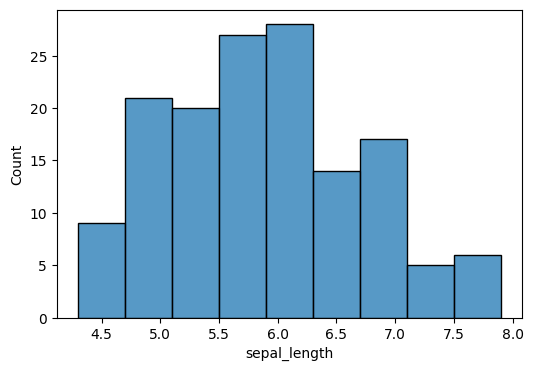

In [68]:
plt.figure(figsize = (6,4))
sns.histplot(df["sepal_length"])


In [69]:
# The graph shows normal distribution of sepal length.

<Axes: xlabel='sepal_length', ylabel='Count'>

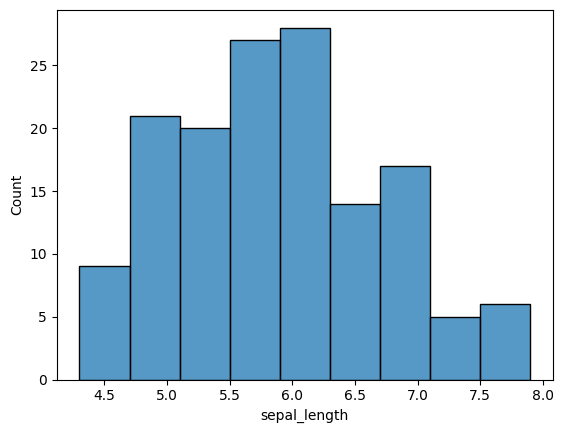

In [70]:
sns.histplot(df["sepal_length"])
# The graph shows normal distribution of sepal width.

<Axes: xlabel='petal_length', ylabel='Count'>

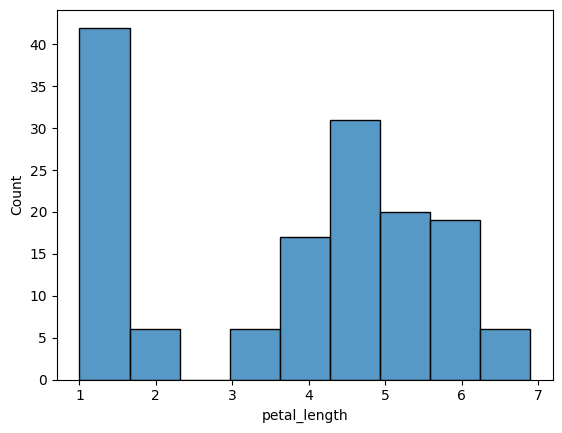

In [71]:
sns.histplot(df["petal_length"])

In [72]:
# The histogram shows that the petal_length is mostly 1.4 and 1.3. The graph is right skewed.

<Axes: xlabel='petal_width', ylabel='Count'>

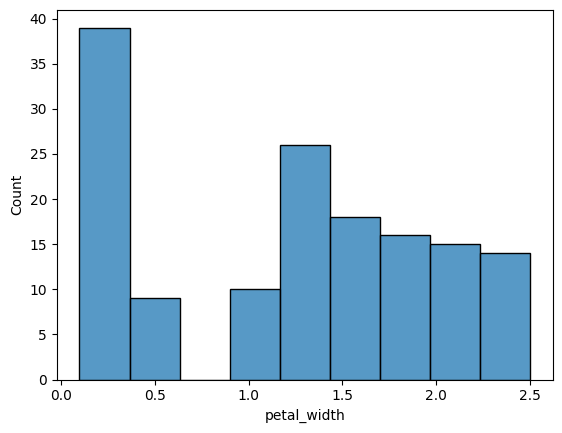

In [73]:
sns.histplot(df["petal_width"])

In [74]:
# The histogram shows that the petal width is mostly between 0.2 and 0.3. The graph is right skewed.

Removing Target Column 

In [75]:
x = df.drop("species", axis=1)
y = df["species"]


Train Test Split

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [77]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

In [ ]:
y_pred

In [ ]:
print("---Enter Flower Details---")
sepal_length = float(input("Enter sepal length: "))
sepal_width = float(input("Enter sepal width: "))
petal_length = float(input("Enter petal length: "))
petal_width = float(input("Enter petal width: "))

---Enter Flower Details---


In [ ]:
user_df = pd.DataFrame(0 , index=[0], columns = x.columns)
user_df["sepal_length"] = sepal_length
user_df["sepal_width"] = sepal_width
user_df["petal_length"] = petal_length
user_df["petal_width"] = petal_width

In [ ]:
user_input_scaled = scaler.transform(user_df)
prediction = model.predict(user_input_scaled)
print("The predicted species of the flower is:", prediction[0])
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
final_accuracy = accuracy * 100
print("The accuracy of the model is:", final_accuracy)

The predicted species of the flower is: Iris-virginica
The accuracy of the model is: 93.33333333333333


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



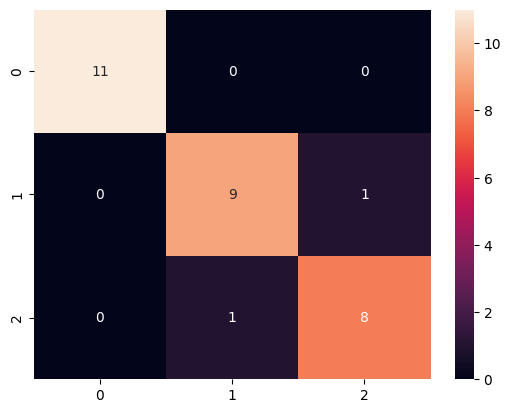

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)


sns.heatmap(cm , annot=True)
plt.show()